<a href="https://colab.research.google.com/github/Netraa07/Assignment_1/blob/main/Assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Country-data.csv to Country-data (2).csv
Saving data-dictionary.csv to data-dictionary.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Country-data.csv")
dictionary = pd.read_csv("data-dictionary.csv")

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (167, 10)


In [ ]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [ ]:
dictionary

,Column Name,Description
0,country,Name of the country
1,child_mort,Death of children under 5 years of age per 100...
2,exports,Exports of goods and services per capita. Give...
3,health,Total health spending per capita. Given as %ag...
4,imports,Imports of goods and services per capita. Give...
5,Income,Net income per person
6,Inflation,The measurement of the annual growth rate of t...
7,life_expec,The average number of years a new born child w...
8,total_fer,The number of children that would be born to e...
9,gdpp,The GDP per capita. Calculated as the Total GD...


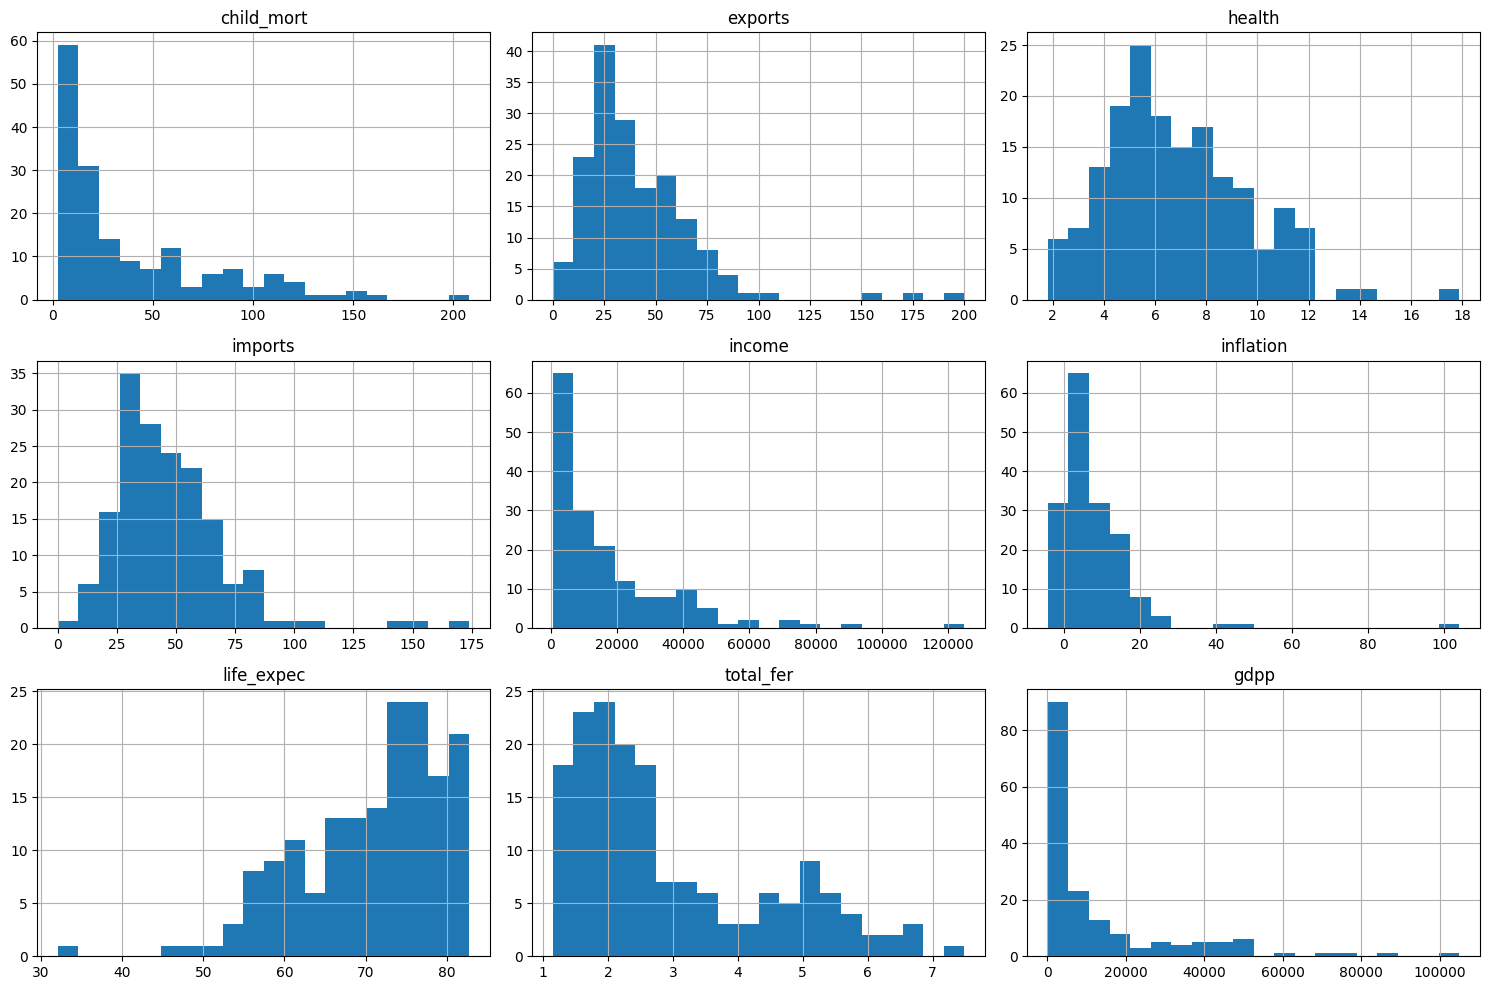

In [ ]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

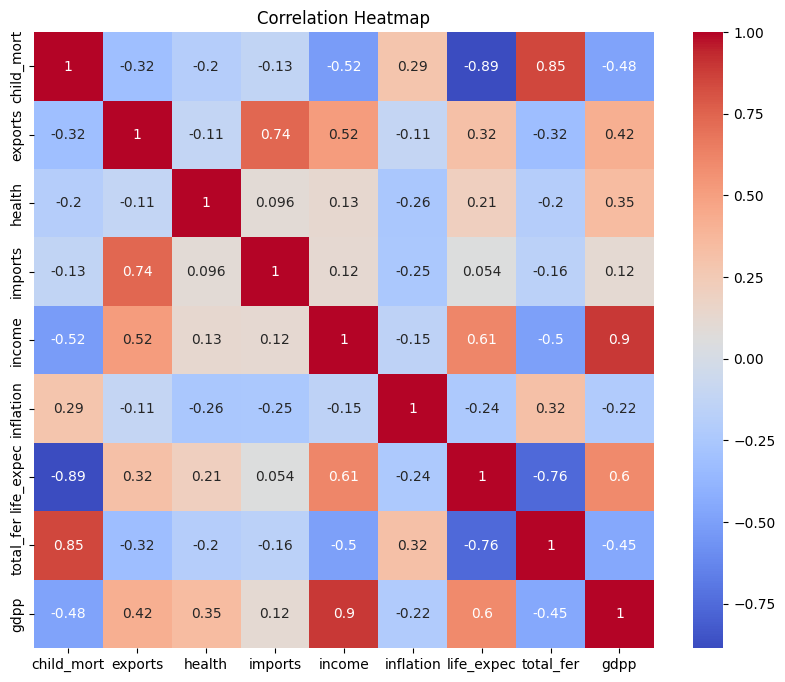

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(df.drop('country', axis=1).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
plt.figure(figsize=(18,12))

for i, col in enumerate(df.columns[1:],1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

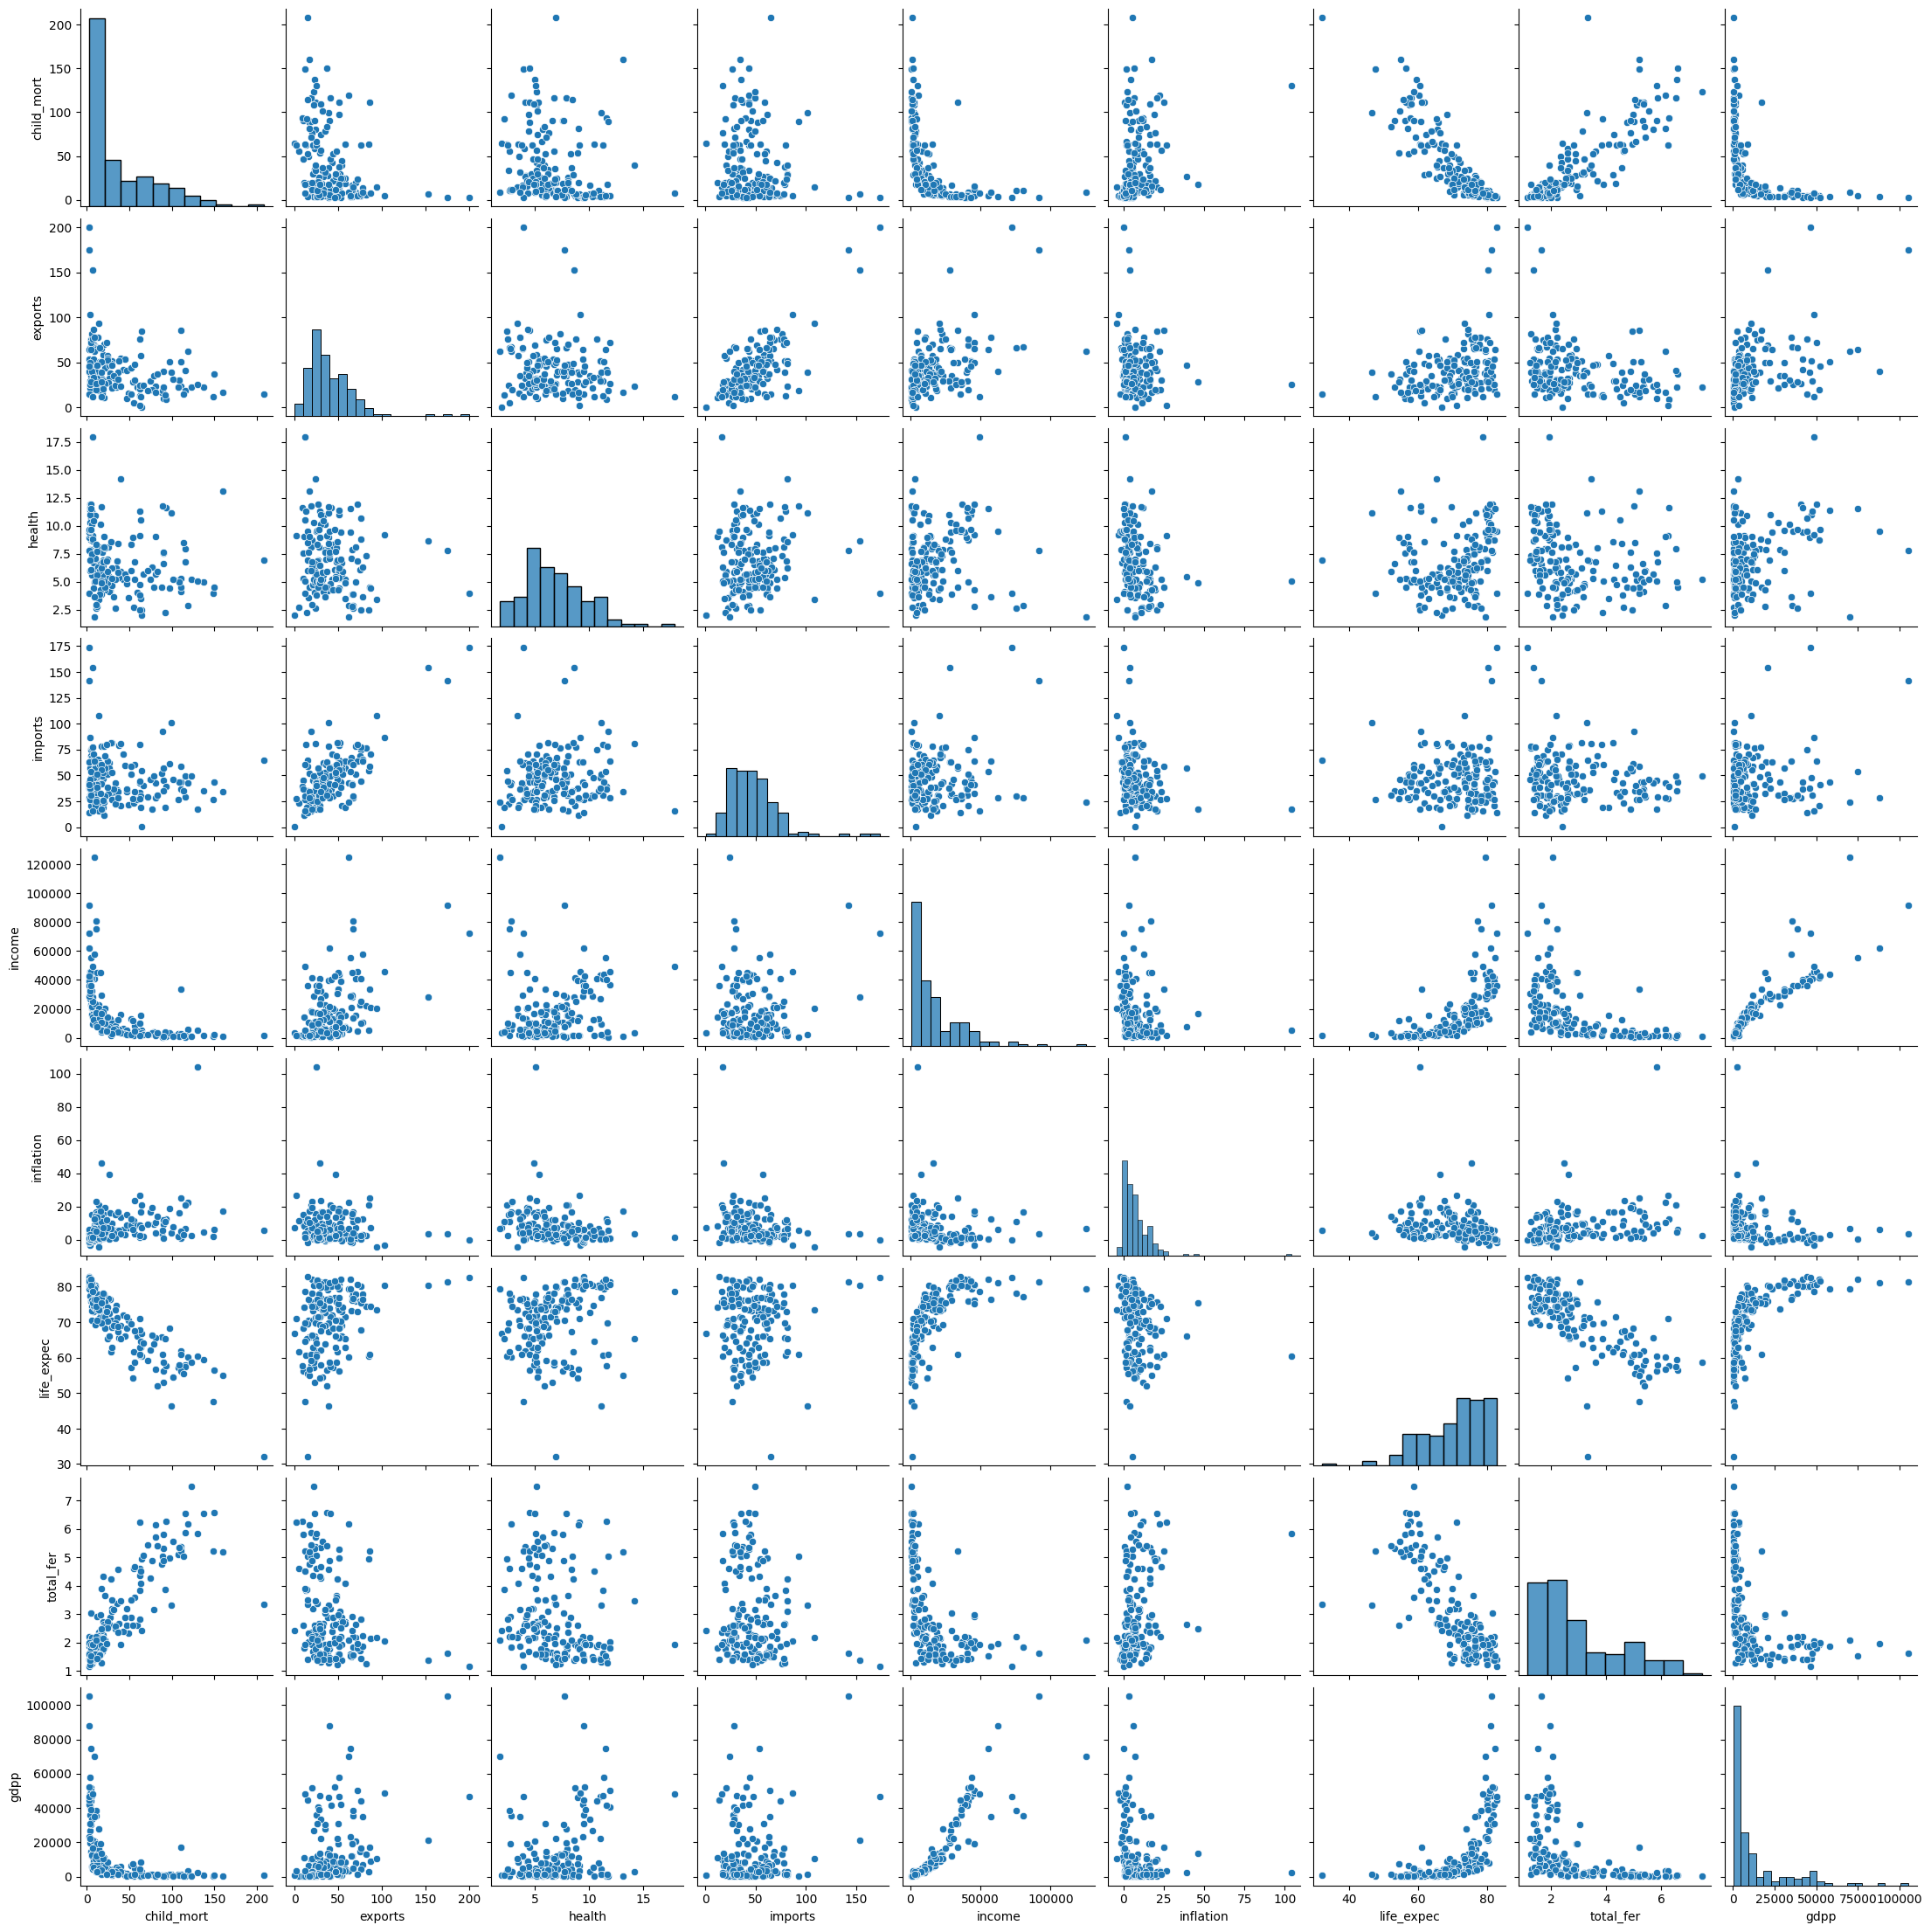

In [ ]:
sns.pairplot(df.drop('country', axis=1))
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df.drop('country', axis=1))

In [ ]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns[1:]
)

scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [ ]:
scaled_df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02
mean,-3.722904e-17,2.127373e-16,5.504579e-16,2.765585e-16,-7.977650e-17,-1.063687e-17,3.696311e-16,3.044803e-16,5.850277e-17
std,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00
min,-8.871383e-01,-1.500192e+00,-1.827827e+00,-1.939940e+00,-8.603259e-01,-1.137852e+00,-4.337186e+00,-1.191250e+00,-6.968005e-01
25%,-7.466190e-01,-6.333367e-01,-6.922106e-01,-6.914785e-01,-7.174558e-01,-5.666409e-01,-5.927576e-01,-7.639023e-01,-6.366596e-01
50%,-4.717981e-01,-2.235279e-01,-1.810007e-01,-1.487432e-01,-3.738080e-01,-2.269504e-01,2.869576e-01,-3.564309e-01,-4.544309e-01
75%,5.926666e-01,3.747198e-01,6.515412e-01,4.913530e-01,2.942370e-01,2.816364e-01,7.042584e-01,6.175252e-01,5.942100e-02
max,4.221297e+00,5.813835e+00,4.047436e+00,5.266181e+00,5.611542e+00,9.129718e+00,1.380962e+00,3.009349e+00,5.036507e+00


In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

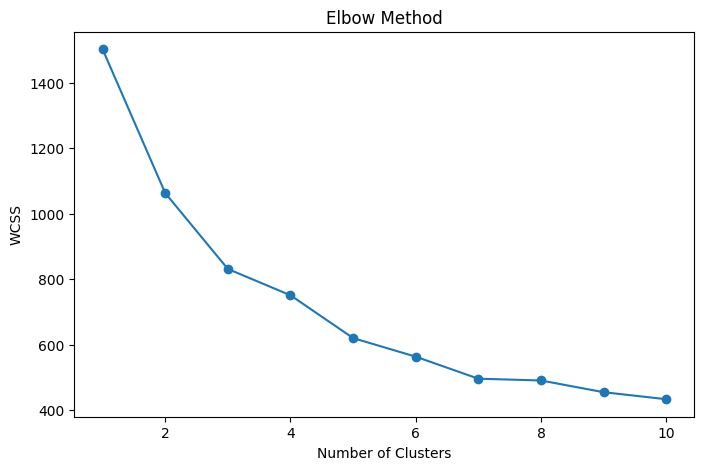

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(scaled_df)

In [ ]:
df["Cluster"] = clusters

In [ ]:
df[["country","Cluster"]].head(20)

,country,Cluster
0,Afghanistan,2
1,Albania,0
2,Algeria,0
3,Angola,2
4,Antigua and Barbuda,0
5,Argentina,0
6,Armenia,0
7,Australia,1
8,Austria,1
9,Azerbaijan,0


In [ ]:

df["Cluster"].value_counts()


,count
Cluster,
0,86
2,45
1,36


In [ ]:
df.groupby("Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


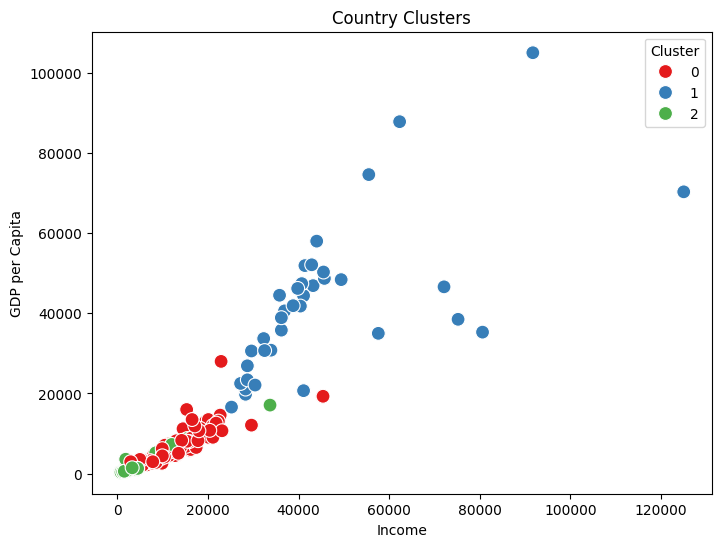

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["income"],
    y=df["gdpp"],
    hue=df["Cluster"],
    palette="Set1",
    s=100
)

plt.title("Country Clusters")
plt.xlabel("Income")
plt.ylabel("GDP per Capita")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)

db_clusters = dbscan.fit_predict(scaled_df)

In [ ]:
df["DBSCAN_Cluster"] = db_clusters

In [ ]:
df[["country", "DBSCAN_Cluster"]].head(20)

,country,DBSCAN_Cluster
0,Afghanistan,0
1,Albania,0
2,Algeria,0
3,Angola,-1
4,Antigua and Barbuda,0
5,Argentina,0
6,Armenia,0
7,Australia,0
8,Austria,0
9,Azerbaijan,0


In [ ]:
df[["country", "DBSCAN_Cluster"]].head(20)

,country,DBSCAN_Cluster
0,Afghanistan,0
1,Albania,0
2,Algeria,0
3,Angola,-1
4,Antigua and Barbuda,0
5,Argentina,0
6,Armenia,0
7,Australia,0
8,Austria,0
9,Azerbaijan,0


In [ ]:
df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,137
-1,30


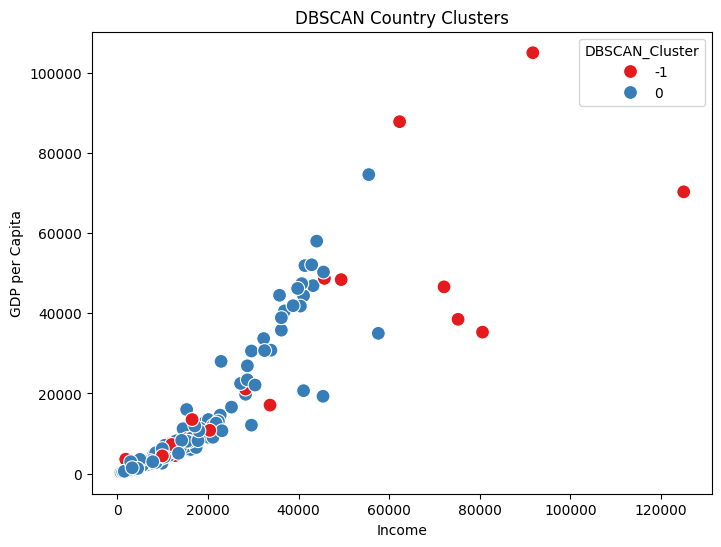

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["income"],
    y=df["gdpp"],
    hue=df["DBSCAN_Cluster"],
    palette="Set1",
    s=100
)

plt.title("DBSCAN Country Clusters")
plt.xlabel("Income")
plt.ylabel("GDP per Capita")
plt.show()

In [ ]:
# Create target variable based on GDP

df['Development_Level'] = pd.qcut(
    df['gdpp'],
    q=3,
    labels=[0,1,2]
)

In [ ]:
df[['country','gdpp','Development_Level']].head(15)

,country,gdpp,Development_Level
0,Afghanistan,553,0
1,Albania,4090,1
2,Algeria,4460,1
3,Angola,3530,1
4,Antigua and Barbuda,12200,2
5,Argentina,10300,1
6,Armenia,3220,1
7,Australia,51900,2
8,Austria,46900,2
9,Azerbaijan,5840,1


In [ ]:
df['Development_Level'].value_counts()

,count
Development_Level,
0,56
2,56
1,55


In [ ]:
X = df.drop(
    ['country','Cluster','DBSCAN_Cluster','Development_Level'],
    axis=1
)

y = df['Development_Level']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test,rf_pred))

Accuracy: 1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        11

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



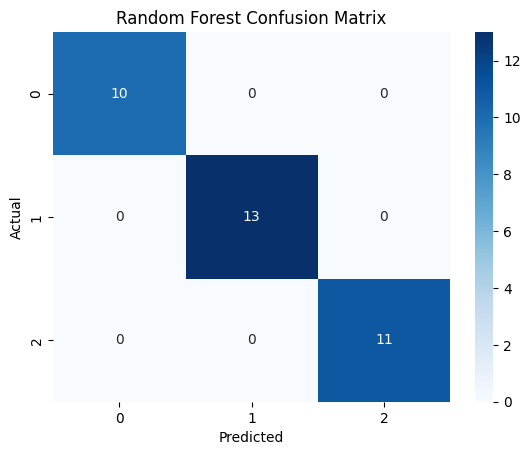

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,rf_pred)

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

In [ ]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 1.0


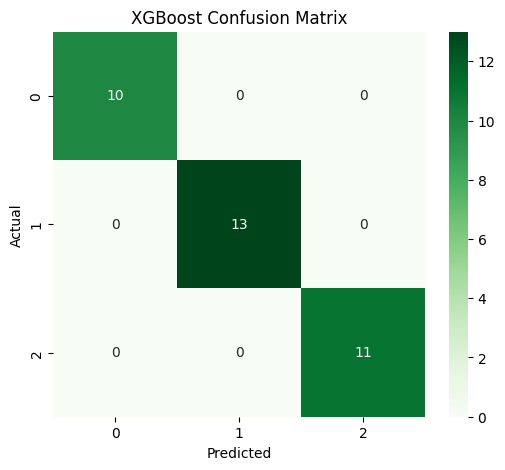

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Greens",
    fmt="d"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

comparison = pd.DataFrame({
    "Model":["Random Forest","XGBoost"],
    "Accuracy":[rf_acc,xgb_acc]
})

comparison

,Model,Accuracy
0,Random Forest,1.0
1,XGBoost,1.0


In [ ]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
8,gdpp,0.972506
4,income,0.026570
3,imports,0.000284
2,health,0.000167
5,inflation,0.000158
6,life_expec,0.000124
1,exports,0.000110
7,total_fer,0.000080
0,child_mort,0.000000


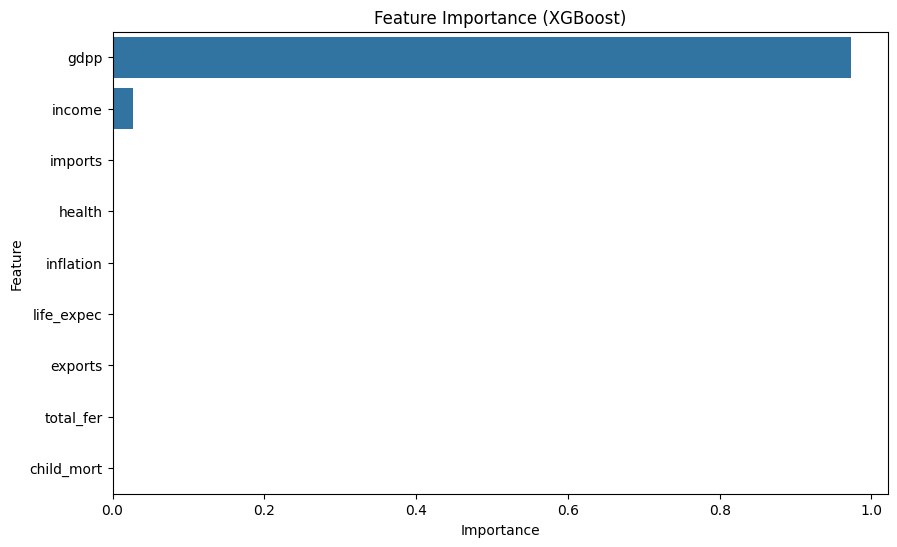

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance (XGBoost)")

plt.show()

In [ ]:
import joblib

joblib.dump(xgb, "Country_Intelligence_Model.pkl")

['Country_Intelligence_Model.pkl']

In [ ]:
from google.colab import files

files.download("Country_Intelligence_Model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Map cluster numbers to names (modify if your clusters represent something different)
cluster_map = {
    0: "Developed",
    1: "Developing",
    2: "Underdeveloped"
}

# Map development levels
development_map = {
    0: "Low",
    1: "Medium",
    2: "High"
}

# Generate recommendations
def recommendation(level):
    if level == "High":
        return "Maintain economic stability"
    elif level == "Medium":
        return "Increase healthcare and education investment"
    else:
        return "Prioritize healthcare, education, and infrastructure"

# Create final output table
result = df[['country', 'Cluster', 'Development_Level']].copy()

result['Cluster'] = result['Cluster'].map(cluster_map)
result['Development_Level'] = result['Development_Level'].astype(int).map(development_map)
result['Recommendation'] = result['Development_Level'].apply(recommendation)

result.head(10)

,country,Cluster,Development_Level,Recommendation
0,Afghanistan,Underdeveloped,Low,"Prioritize healthcare, education, and infrastr..."
1,Albania,Developed,Medium,Increase healthcare and education investment
2,Algeria,Developed,Medium,Increase healthcare and education investment
3,Angola,Underdeveloped,Medium,Increase healthcare and education investment
4,Antigua and Barbuda,Developed,High,Maintain economic stability
5,Argentina,Developed,Medium,Increase healthcare and education investment
6,Armenia,Developed,Medium,Increase healthcare and education investment
7,Australia,Developing,High,Maintain economic stability
8,Austria,Developing,High,Maintain economic stability
9,Azerbaijan,Developed,Medium,Increase healthcare and education investment
